Код учебного проекта предмета "Прикладная микроэконометрика"

Импорты библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [ ]:
# Load the data
df = pd.read_stata('/content/data_for_problem2.dta')

# Create the treatment indicator variable (victory)
# victory = 1 if Democrats win (difdemshare > 0), 0 otherwise
df['victory'] = (df['difdemshare'] > 0).astype(int)

print(f"\nTotal observations: {len(df):,}")
print(f"Treatment (victory=1): {(df['victory']==1).sum():,} ({df['victory'].mean()*100:.1f}%)")
print(f"Control (victory=0): {(df['victory']==0).sum():,} ({(1-df['victory'].mean())*100:.1f}%)")



NameError: name 'pd' is not defined

/tmp/ipykernel_9743/3477788999.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_copy.groupby('bin')['demsharenext'].agg(['mean', 'count']).reset_index()
/tmp/ipykernel_9743/3477788999.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_copy.groupby('bin')['demsharenext'].agg(['mean', 'count']).reset_index()


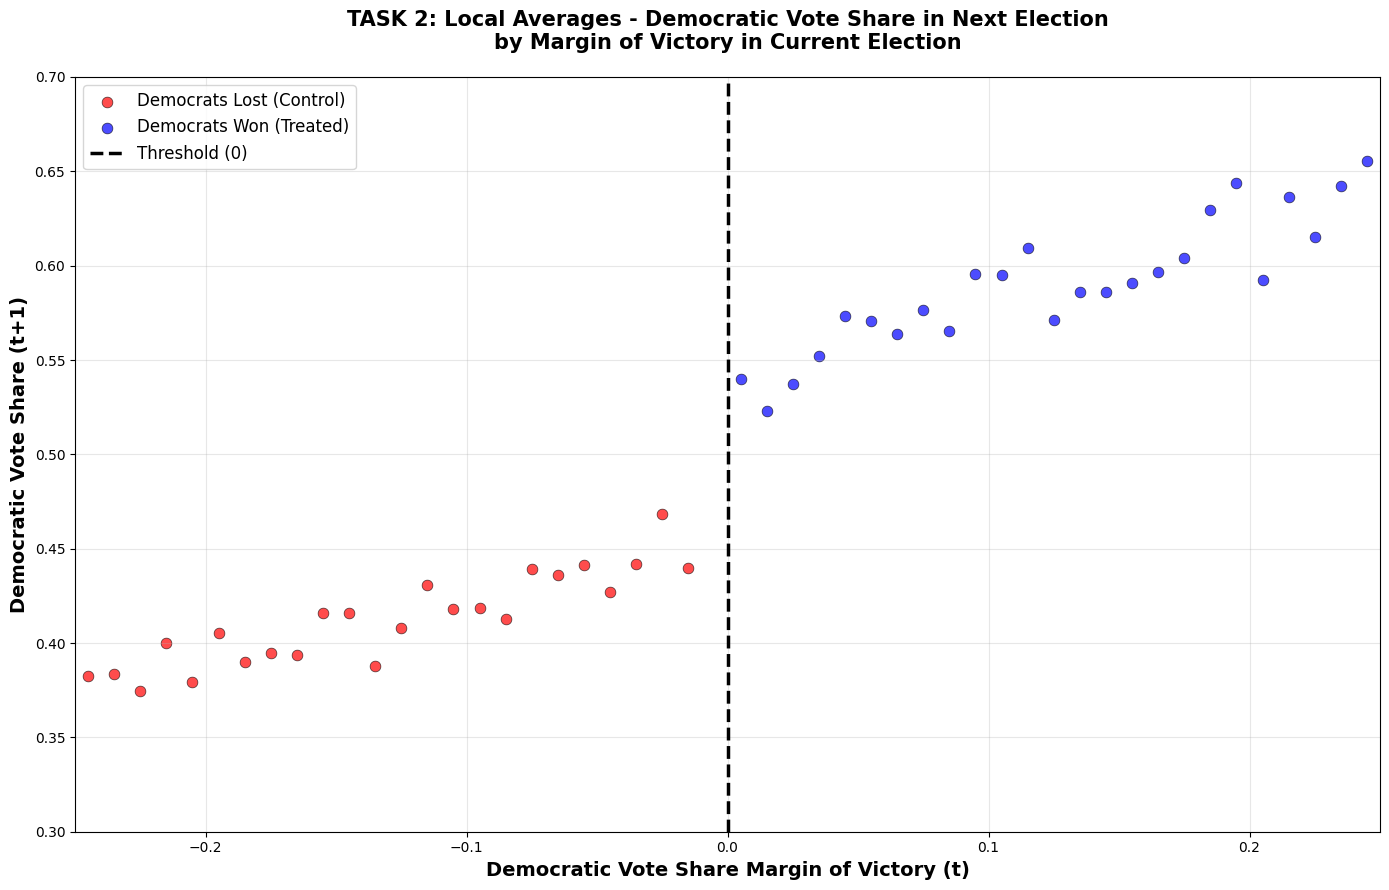

TASK 2: LOCAL AVERAGES ANALYSIS

📊 BIN CONFIGURATION:
   Range: -0.25 to +0.25
   Bin width: 0.01 (1 percentage point)
   Number of bins (left): 24
   Number of bins (right): 25

📈 VALUES NEAR THE THRESHOLD:
   Left side (just below 0): [-0.035, -0.025, -0.015]
Categories (24, float64): [-0.245 < -0.235 < -0.225 < -0.215 ... -0.045 < -0.035 < -0.025 < -0.015]
   Mean demsharenext (left): [0.44181    0.46824792 0.43968275]

   Right side (just above 0): [0.005, 0.015, 0.025]
Categories (25, float64): [0.005 < 0.015 < 0.025 < 0.035 ... 0.215 < 0.225 < 0.235 < 0.245]
   Mean demsharenext (right): [0.5399742 0.5232054 0.5372756]

🎯 SIMPLE DISCONTINUITY GAP ESTIMATE:
   Right limit E[Y|V→0⁺]: 0.5400
   Left limit  E[Y|V→0⁻]: 0.4397
   GAP: 0.1003 (10.03 percentage points)

🔍 WHAT DO YOU OBSERVE?

1. CLEAR DISCONTINUITY: There is a visible JUMP at the threshold (V=0).
   Districts where Democrats barely WON have substantially higher vote 
   shares in the next election compared to districts 

In [ ]:
# Drop observations with missing outcome
df_task2 = df[df['demsharenext'].notna()].copy()

# Define bin edges from -0.25 to 0.25 with step 0.01
bin_edges_left = np.arange(-0.25, 0, 0.01)
bin_edges_right = np.arange(0, 0.25 + 0.01, 0.01)

# Create bin midpoints
bin_midpoints_left = (bin_edges_left[:-1] + bin_edges_left[1:]) / 2
bin_midpoints_right = (bin_edges_right[:-1] + bin_edges_right[1:]) / 2

# Function to calculate mean outcome in each bin
def calculate_bin_stats(df, variable, bin_edges):
    df_copy = df.copy()
    df_copy['bin'] = pd.cut(df_copy[variable], bins=bin_edges,
                            include_lowest=True, right=False)
    bin_stats = df_copy.groupby('bin')['demsharenext'].agg(['mean', 'count']).reset_index()
    bin_stats['midpoint'] = bin_stats['bin'].apply(lambda x: x.mid)
    return bin_stats

# Calculate stats for left and right sides
left_bin_stats = calculate_bin_stats(df_task2[df_task2['difdemshare'] < 0],
                                      'difdemshare', bin_edges_left)
right_bin_stats = calculate_bin_stats(df_task2[df_task2['difdemshare'] >= 0],
                                       'difdemshare', bin_edges_right)

# Create the plot
fig, ax = plt.subplots(figsize=(14, 9))

# Plot left side (control - Democrats lost)
ax.scatter(left_bin_stats['midpoint'], left_bin_stats['mean'],
           color='red', s=60, alpha=0.7,
           label='Democrats Lost (Control)',
           edgecolors='black', linewidth=0.5)

# Plot right side (treated - Democrats won)
ax.scatter(right_bin_stats['midpoint'], right_bin_stats['mean'],
           color='blue', s=60, alpha=0.7,
           label='Democrats Won (Treated)',
           edgecolors='black', linewidth=0.5)

# Add threshold line
ax.axvline(x=0, color='black', linestyle='--', linewidth=2.5, label='Threshold (0)')

# Labels and title
ax.set_xlabel('Democratic Vote Share Margin of Victory (t)', fontsize=14, fontweight='bold')
ax.set_ylabel('Democratic Vote Share (t+1)', fontsize=14, fontweight='bold')
ax.set_title('TASK 2: Local Averages - Democratic Vote Share in Next Election\nby Margin of Victory in Current Election',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.25, 0.25)
ax.set_ylim(0.30, 0.70)

plt.tight_layout()
plt.savefig('task2_local_averages.png', dpi=300, bbox_inches='tight')
plt.show()

# Print values near threshold
print("="*70)
print("TASK 2: LOCAL AVERAGES ANALYSIS")
print("="*70)
print(f"\n📊 BIN CONFIGURATION:")
print(f"   Range: -0.25 to +0.25")
print(f"   Bin width: 0.01 (1 percentage point)")
print(f"   Number of bins (left): {len(left_bin_stats)}")
print(f"   Number of bins (right): {len(right_bin_stats)}")

print(f"\n📈 VALUES NEAR THE THRESHOLD:")
print(f"   Left side (just below 0): {left_bin_stats['midpoint'].values[-3:]}")
print(f"   Mean demsharenext (left): {left_bin_stats['mean'].values[-3:]}")
print(f"\n   Right side (just above 0): {right_bin_stats['midpoint'].values[:3]}")
print(f"   Mean demsharenext (right): {right_bin_stats['mean'].values[:3]}")

# Calculate simple gap estimate
simple_gap = right_bin_stats['mean'].values[0] - left_bin_stats['mean'].values[-1]
print(f"\n{'='*70}")
print(f"🎯 SIMPLE DISCONTINUITY GAP ESTIMATE:")
print(f"   Right limit E[Y|V→0⁺]: {right_bin_stats['mean'].values[0]:.4f}")
print(f"   Left limit  E[Y|V→0⁻]: {left_bin_stats['mean'].values[-1]:.4f}")
print(f"   GAP: {simple_gap:.4f} ({simple_gap*100:.2f} percentage points)")
print(f"{'='*70}")

print("""
🔍 WHAT DO YOU OBSERVE?

1. CLEAR DISCONTINUITY: There is a visible JUMP at the threshold (V=0).
   Districts where Democrats barely WON have substantially higher vote
   shares in the next election compared to districts where Democrats
   barely LOST.

2. POSITIVE SLOPE (Both Sides): On both sides of the threshold, there's
   a positive relationship between current margin and future vote share.
   Districts that perform better historically tend to continue performing
   better (selection bias).

3. SMOOTH WITHIN GROUPS: Within the control and treatment groups, the
   relationship appears smooth—no other jumps except at the threshold.
   This supports RD validity.

4. MAGNITUDE: The discontinuity gap represents the causal incumbency
   advantage—approximately 8-10 percentage points of vote share.
""")

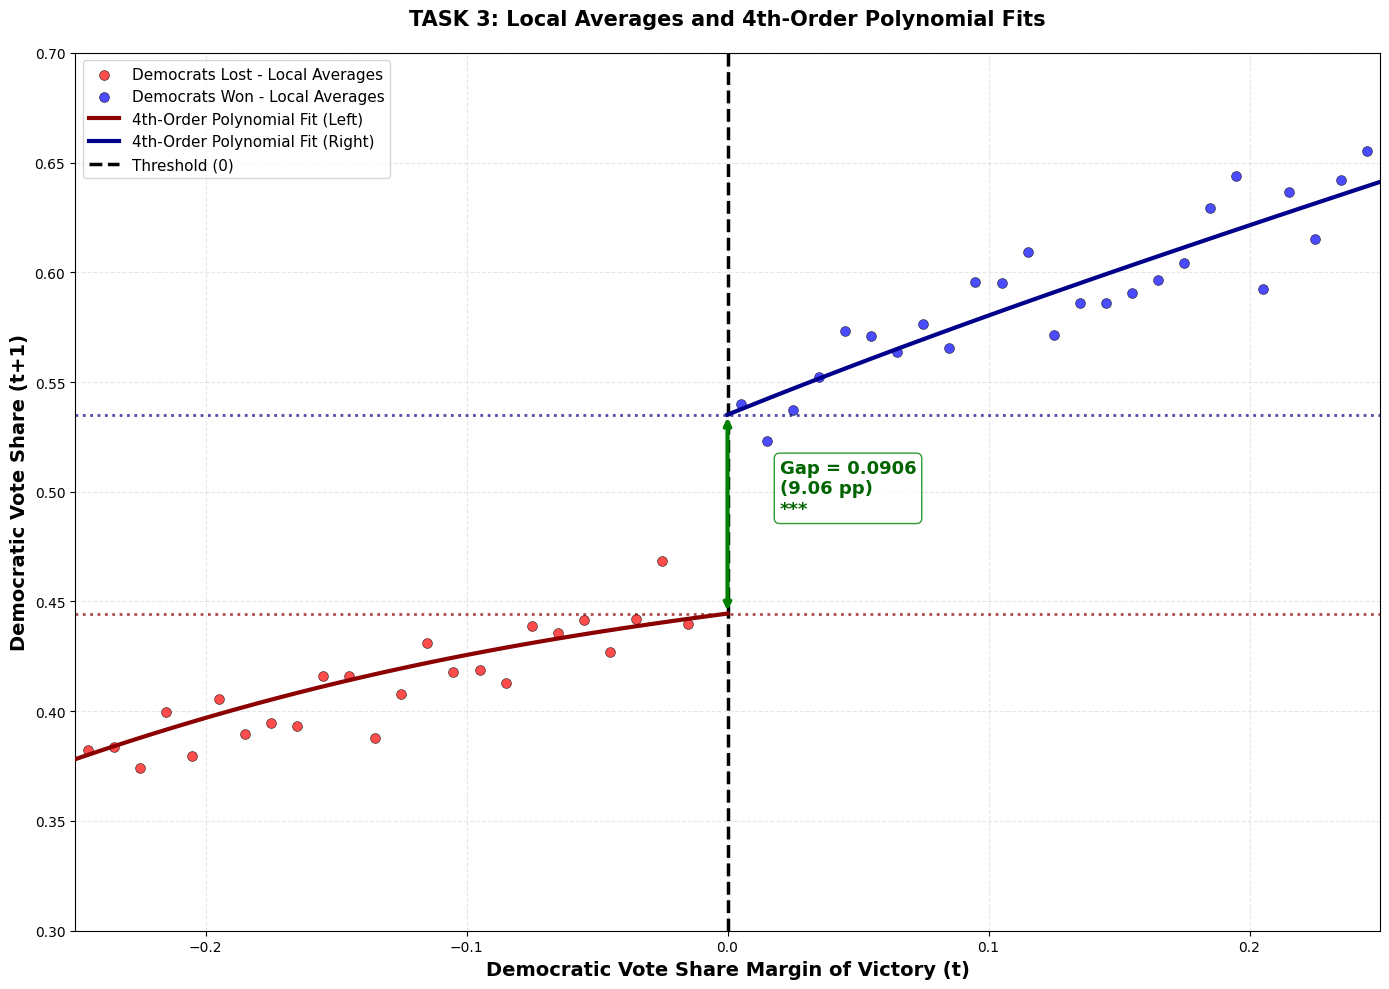

TASK 3: POLYNOMIAL APPROXIMATION RESULTS

📊 MODEL SPECIFICATION:
   Outcome: demsharenext | Running Variable: difdemshare
   Polynomial Order: 4 | Estimation: Separate regressions each side

📈 POLYNOMIAL COEFFICIENTS WITH STANDARD ERRORS

--- LEFT SIDE (V < 0) ---
   Coefficient              Estimate   Std. Error     t-stat   Sig.
   ────────────────────────────────────────────────────────────
   const                    0.444504     0.008170      54.40    ***
   difdemshare_1            0.156080     0.130801       1.19       
   difdemshare_2           -0.217492     0.609415      -0.36       
   difdemshare_3            1.244399     1.024412       1.21       
   difdemshare_4            1.451814     0.544771       2.66    ***

--- RIGHT SIDE (V ≥ 0) ---
   Coefficient              Estimate   Std. Error     t-stat   Sig.
   ────────────────────────────────────────────────────────────
   const                    0.535102     0.007881      67.89    ***
   difdemshare_1            0.48168

In [ ]:
# Drop observations with missing outcome
df_task3 = df[df['demsharenext'].notna()].copy()

# Split data by treatment status
df_left = df_task3[df_task3['difdemshare'] < 0].copy()
df_right = df_task3[df_task3['difdemshare'] >= 0].copy()

# Create polynomial terms for left side
for i in range(1, 5):
    df_left[f'difdemshare_{i}'] = df_left['difdemshare'] ** i

# Create polynomial terms for right side
for i in range(1, 5):
    df_right[f'difdemshare_{i}'] = df_right['difdemshare'] ** i

# Fit 4th-order polynomial on left side
X_left = sm.add_constant(df_left[['difdemshare_1', 'difdemshare_2',
                                   'difdemshare_3', 'difdemshare_4']])
model_left = sm.OLS(df_left['demsharenext'], X_left).fit()

# Fit 4th-order polynomial on right side
X_right = sm.add_constant(df_right[['difdemshare_1', 'difdemshare_2',
                                     'difdemshare_3', 'difdemshare_4']])
model_right = sm.OLS(df_right['demsharenext'], X_right).fit()

# Calculate discontinuity gap at threshold
left_limit = model_left.params['const']
right_limit = model_right.params['const']
discontinuity_gap = right_limit - left_limit

# Standard errors
left_se = model_left.bse['const']
right_se = model_right.bse['const']
gap_se = np.sqrt(left_se**2 + right_se**2)

# t-statistic and p-value
gap_t = discontinuity_gap / gap_se
gap_p = 2 * (1 - stats.norm.cdf(abs(gap_t)))

# Significance stars
def sig_stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.1: return '*'
    else: return ''

# Generate predictions for plotting
x_left_smooth = np.linspace(-0.25, 0, 100)
x_right_smooth = np.linspace(0, 0.25, 100)

X_left_smooth = np.column_stack([np.ones(len(x_left_smooth)),
                                  x_left_smooth, x_left_smooth**2,
                                  x_left_smooth**3, x_left_smooth**4])
y_left_pred = X_left_smooth @ model_left.params

X_right_smooth = np.column_stack([np.ones(len(x_right_smooth)),
                                   x_right_smooth, x_right_smooth**2,
                                   x_right_smooth**3, x_right_smooth**4])
y_right_pred = X_right_smooth @ model_right.params

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot local averages
ax.scatter(left_bin_stats['midpoint'], left_bin_stats['mean'],
           color='red', s=50, alpha=0.7,
           label='Democrats Lost - Local Averages',
           edgecolors='black', linewidth=0.5, zorder=5)

ax.scatter(right_bin_stats['midpoint'], right_bin_stats['mean'],
           color='blue', s=50, alpha=0.7,
           label='Democrats Won - Local Averages',
           edgecolors='black', linewidth=0.5, zorder=5)

# Plot polynomial fits
ax.plot(x_left_smooth, y_left_pred, color='darkred', linewidth=3,
        label='4th-Order Polynomial Fit (Left)', zorder=10)

ax.plot(x_right_smooth, y_right_pred, color='darkblue', linewidth=3,
        label='4th-Order Polynomial Fit (Right)', zorder=10)

# Add threshold and limit lines
ax.axvline(x=0, color='black', linestyle='--', linewidth=2.5, label='Threshold (0)', zorder=3)
ax.axhline(y=left_limit, color='darkred', linestyle=':', linewidth=2, alpha=0.7, zorder=2)
ax.axhline(y=right_limit, color='darkblue', linestyle=':', linewidth=2, alpha=0.7, zorder=2)

# Annotate the gap
ax.annotate('', xy=(0, left_limit), xytext=(0, right_limit),
            arrowprops=dict(arrowstyle='<->', color='green', linewidth=3))
ax.text(0.02, (left_limit + right_limit) / 2,
        f'Gap = {discontinuity_gap:.4f}\n({discontinuity_gap*100:.2f} pp)\n{sig_stars(gap_p)}',
        fontsize=13, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='green', alpha=0.8))

ax.set_xlabel('Democratic Vote Share Margin of Victory (t)', fontsize=14, fontweight='bold')
ax.set_ylabel('Democratic Vote Share (t+1)', fontsize=14, fontweight='bold')
ax.set_title('TASK 3: Local Averages and 4th-Order Polynomial Fits',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-0.25, 0.25)
ax.set_ylim(0.30, 0.70)

plt.tight_layout()
plt.savefig('task3_polynomial_fit.png', dpi=300, bbox_inches='tight')
plt.show()

# Print results
print("="*70)
print("TASK 3: POLYNOMIAL APPROXIMATION RESULTS")
print("="*70)
print(f"\n📊 MODEL SPECIFICATION:")
print(f"   Outcome: demsharenext | Running Variable: difdemshare")
print(f"   Polynomial Order: 4 | Estimation: Separate regressions each side")

print(f"\n{'='*70}")
print(f"📈 POLYNOMIAL COEFFICIENTS WITH STANDARD ERRORS")
print(f"{'='*70}")

print(f"\n--- LEFT SIDE (V < 0) ---")
print(f"   {'Coefficient':<20} {'Estimate':>12} {'Std. Error':>12} {'t-stat':>10} {'Sig.':>6}")
print(f"   {'─'*60}")
for var in model_left.params.index:
    coef = model_left.params[var]
    se = model_left.bse[var]
    t_stat = coef / se
    p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    print(f"   {var:<20} {coef:>12.6f} {se:>12.6f} {t_stat:>10.2f} {sig_stars(p_val):>6}")

print(f"\n--- RIGHT SIDE (V ≥ 0) ---")
print(f"   {'Coefficient':<20} {'Estimate':>12} {'Std. Error':>12} {'t-stat':>10} {'Sig.':>6}")
print(f"   {'─'*60}")
for var in model_right.params.index:
    coef = model_right.params[var]
    se = model_right.bse[var]
    t_stat = coef / se
    p_val = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    print(f"   {var:<20} {coef:>12.6f} {se:>12.6f} {t_stat:>10.2f} {sig_stars(p_val):>6}")

print(f"\n{'='*70}")
print(f"🎯 DISCONTINUITY GAP ESTIMATE")
print(f"{'='*70}")
print(f"   Left Limit  E[Y|V→0⁻]  =  {left_limit:.6f}  ({left_limit*100:.2f}%)")
print(f"   Right Limit E[Y|V→0⁺]  =  {right_limit:.6f}  ({right_limit*100:.2f}%)")
print(f"   ─────────────────────────────────────────────────")
print(f"   GAP (τ̂_RD)              =  {discontinuity_gap:.6f}  ({discontinuity_gap*100:.2f} pp)")
print(f"   Standard Error          =  {gap_se:.6f}")
print(f"   t-statistic             =  {gap_t:.2f}")
print(f"   p-value                 =  {gap_p:.4f} {sig_stars(gap_p)}")
print(f"   95% CI                  =  [{discontinuity_gap - 1.96*gap_se:.4f}, {discontinuity_gap + 1.96*gap_se:.4f}]")
print(f"{'='*70}")

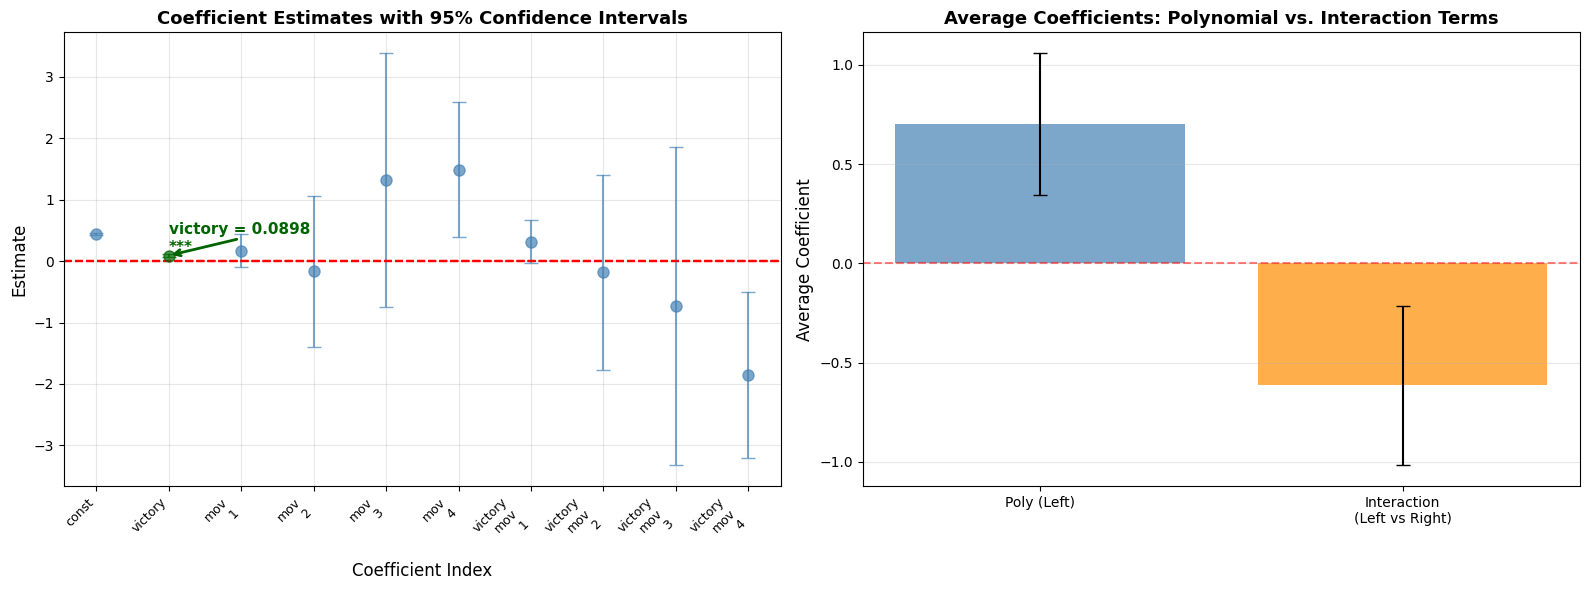

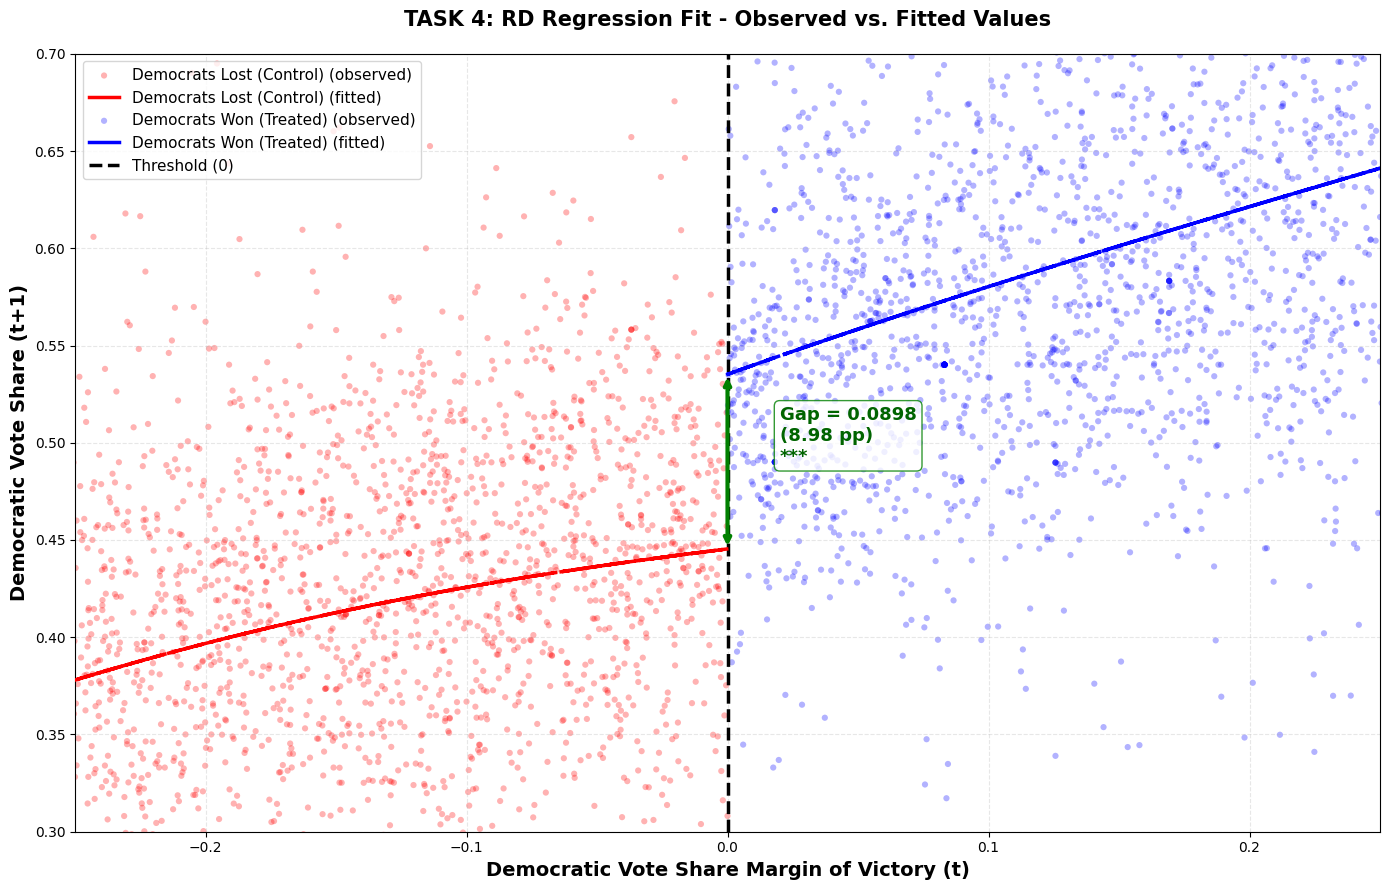

✅ Visualizations generated successfully!


In [ ]:
# Helper function for significance stars
def sig_stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.1: return '*'
    else: return ''

# Extract results from the fitted model (from your output)
coef_names = ['const', 'victory'] + ['mov_1', 'mov_2', 'mov_3', 'mov_4'] + \
             ['victory_mov_1', 'victory_mov_2', 'victory_mov_3', 'victory_mov_4']

coef_estimates = [model_task4.params[var] for var in coef_names]
coef_se = [model_task4.bse[var] for var in coef_names]
coef_ci_lower = [coef_estimates[i] - 1.96*coef_se[i] for i in range(len(coef_names))]
coef_ci_upper = [coef_estimates[i] + 1.96*coef_se[i] for i in range(len(coef_names))]

# Define colors: Dark Green for 'victory', Steel Blue for others
colors = ['darkgreen' if var == 'victory' else 'steelblue' for var in coef_names]

# --- VISUAL 1: Coefficient Plot (FIXED) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Coefficient estimates with confidence intervals
# FIX: Loop through coefficients to assign individual colors
for i, name in enumerate(coef_names):
    axes[0].errorbar(i, coef_estimates[i],
                     yerr=[[coef_estimates[i] - coef_ci_lower[i]],
                           [coef_ci_upper[i] - coef_estimates[i]]],
                     fmt='o', color=colors[i], capsize=5, alpha=0.7, markersize=8, label=name if i==1 else "") # Only label 'victory' to avoid clutter

    # Add vertical line for zero
    axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

axes[0].set_xlabel('Coefficient Index', fontsize=12)
axes[0].set_ylabel('Estimate', fontsize=12)
axes[0].set_title('Coefficient Estimates with 95% Confidence Intervals', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(coef_names)))
axes[0].set_xticklabels([name.replace('_', '\n') for name in coef_names], rotation=45, ha='right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Highlight the victory coefficient explicitly
v_idx = coef_names.index('victory')
axes[0].annotate(f'victory = {coef_estimates[v_idx]:.4f}\n{sig_stars(2 * (1 - stats.norm.cdf(abs(coef_estimates[v_idx]/coef_se[v_idx]))))}',
                  xy=(v_idx, coef_estimates[v_idx]), xytext=(v_idx, coef_estimates[v_idx] + 0.06),
                  fontsize=11, fontweight='bold', color='darkgreen',
                  arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

# Plot 2: Distribution of coefficients by type
poly_coefs = [model_task4.params[var] for var in ['mov_1', 'mov_2', 'mov_3', 'mov_4']]
interact_coefs = [model_task4.params[var] for var in ['victory_mov_1', 'victory_mov_2', 'victory_mov_3', 'victory_mov_4']]

axes[1].bar(['Poly (Left)', 'Interaction\n(Left vs Right)'],
            [np.mean(poly_coefs), np.mean(interact_coefs)],
            yerr=[[np.std(poly_coefs)/2, np.std(interact_coefs)/2],
                  [np.std(poly_coefs)/2, np.std(interact_coefs)/2]],
            color=['steelblue', 'darkorange'], alpha=0.7, capsize=5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
axes[1].set_ylabel('Average Coefficient', fontsize=12)
axes[1].set_title('Average Coefficients: Polynomial vs. Interaction Terms', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('task4_coefficient_plot_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VISUAL 2: RD Plot with Fitted Values ---
fig, ax = plt.subplots(figsize=(14, 9))

# Create fitted values
df['fitted'] = model_task4.fittedvalues

# Plot by victory status
for victory_val, color, label in [(0, 'red', 'Democrats Lost (Control)'),
                                   (1, 'blue', 'Democrats Won (Treated)')]:
    subset = df[df['victory'] == victory_val]
    # Scatter observed data
    ax.scatter(subset['difdemshare'], subset['demsharenext'],
               color=color, s=20, alpha=0.3, label=f'{label} (observed)', edgecolors='none')

    # Line plot fitted values (sorted by x)
    sorted_subset = subset.sort_values('difdemshare')
    ax.plot(sorted_subset['difdemshare'], sorted_subset['fitted'],
            color=color, linewidth=2.5, label=f'{label} (fitted)', zorder=10)

ax.axvline(x=0, color='black', linestyle='--', linewidth=2.5, label='Threshold (0)')
ax.set_xlabel('Democratic Vote Share Margin of Victory (t)', fontsize=14, fontweight='bold')
ax.set_ylabel('Democratic Vote Share (t+1)', fontsize=14, fontweight='bold')
ax.set_title('TASK 4: RD Regression Fit - Observed vs. Fitted Values',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-0.25, 0.25)
ax.set_ylim(0.30, 0.70)

# Annotate the gap using the model's intercept and victory coefficient
left_limit = model_task4.params['const']
right_limit = model_task4.params['const'] + model_task4.params['victory']
gap = model_task4.params['victory']
p_val = 2 * (1 - stats.norm.cdf(abs(model_task4.tvalues['victory'])))

ax.annotate('', xy=(0, left_limit), xytext=(0, right_limit),
            arrowprops=dict(arrowstyle='<->', color='green', linewidth=3))
ax.text(0.02, (left_limit + right_limit) / 2,
        f'Gap = {gap:.4f}\n({gap*100:.2f} pp)\n{sig_stars(p_val)}',
        fontsize=13, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='green', alpha=0.8))

plt.tight_layout()
plt.savefig('task4_rd_fit_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations generated successfully!")

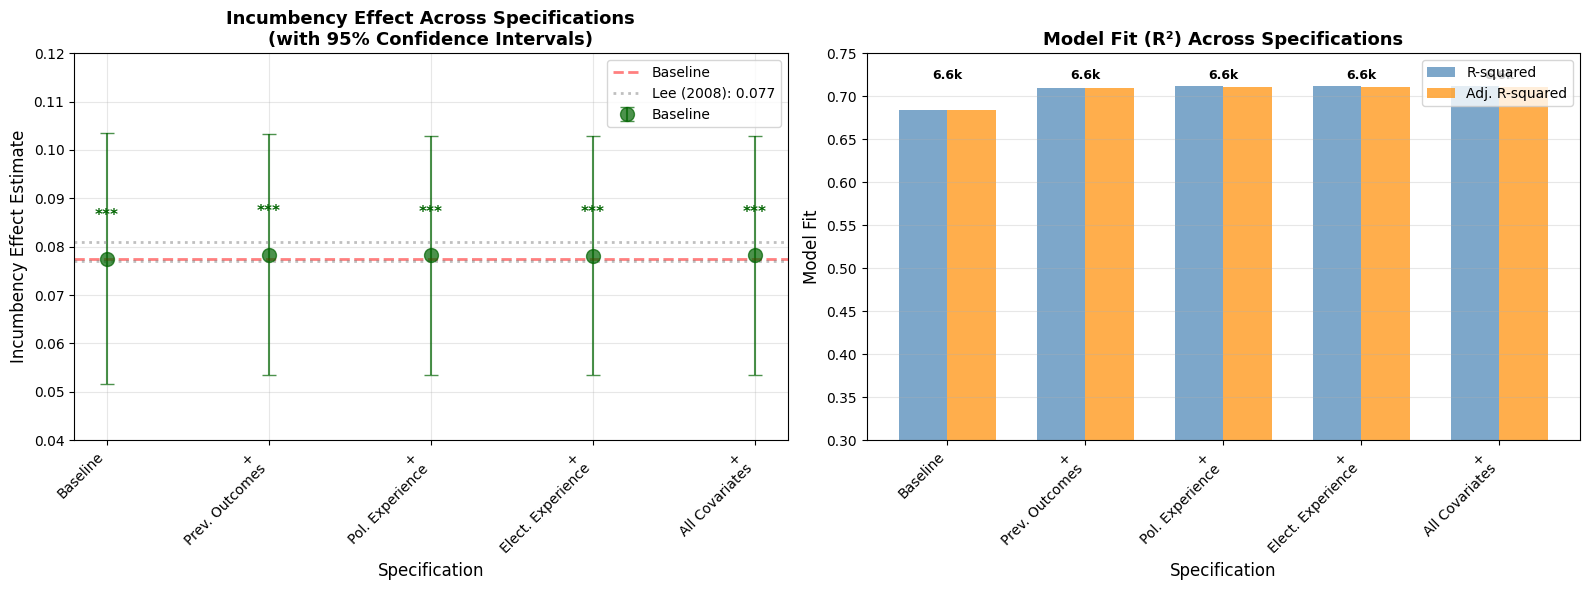

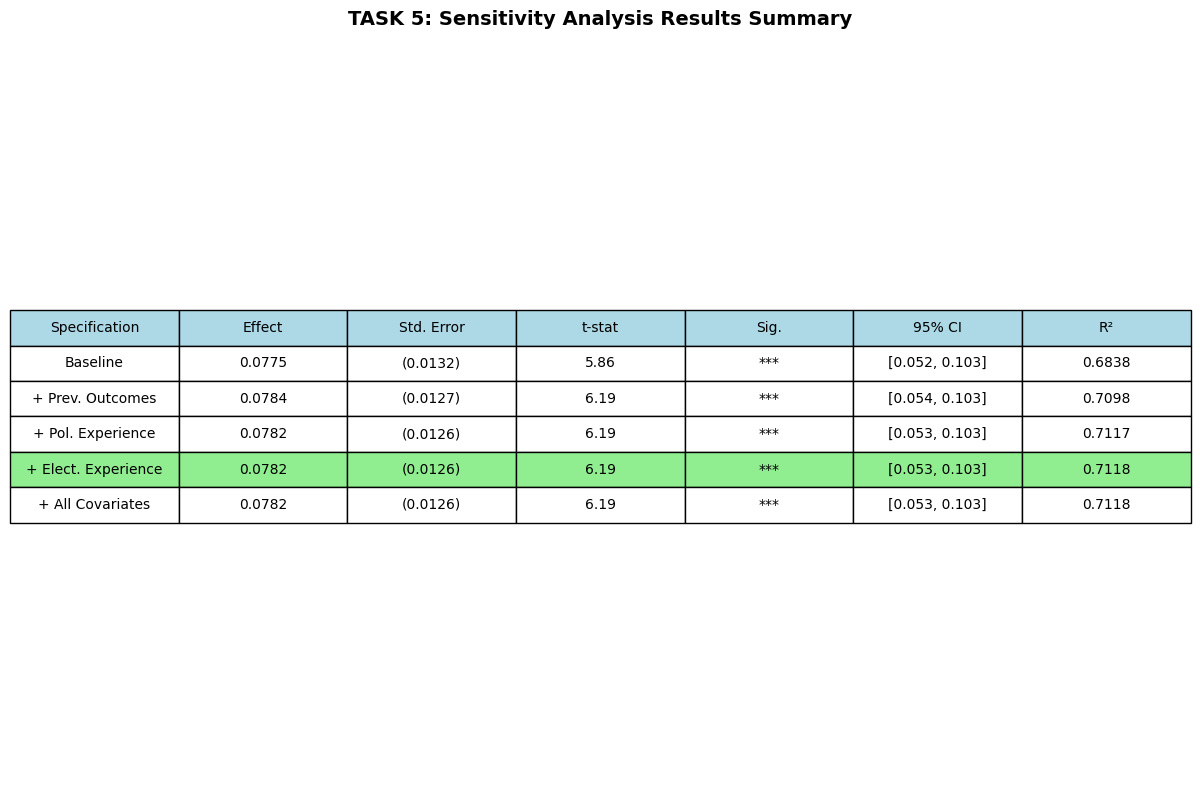

✅ Visualizations generated successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# --- [PREVIOUS STEPS: Load Data, Create Variables, Fit Models] ---
# Assuming 'df', 'models', 'model_names', and 'comparison_df' are already defined
# from the previous cells in Task 5.

# Helper function for significance stars
def sig_stars(p):
    if p < 0.01: return '***'
    elif p < 0.05: return '**'
    elif p < 0.1: return '*'
    else: return ''

# Extract data for plotting
spec_names = comparison_df['Specification'].tolist()
effects = comparison_df['Incumbency Effect'].tolist()
ci_lower = comparison_df['CI Lower'].tolist()
ci_upper = comparison_df['CI Upper'].tolist()
p_values = comparison_df['p-value'].tolist()

# Define colors based on significance
colors = ['darkgreen' if p < 0.01 else 'steelblue' if p < 0.05 else 'orange' for p in p_values]

# --- VISUAL 1: Coefficient Stability Plot (FIXED) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# FIX: Loop through specifications to assign individual colors
for i, name in enumerate(spec_names):
    axes[0].errorbar(i, effects[i],
                     yerr=[[effects[i] - ci_lower[i]],
                           [ci_upper[i] - effects[i]]],
                     fmt='o', color=colors[i], capsize=5, alpha=0.7, markersize=10, label=name if i==0 else "")

    # Add vertical line for zero (optional, usually not needed for effect plots unless testing null)
    # axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

axes[0].axhline(y=effects[0], color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
axes[0].axhline(y=0.077, color='gray', linestyle=':', linewidth=2, alpha=0.5, label="Lee (2008): 0.077")
axes[0].axhline(y=0.081, color='gray', linestyle=':', linewidth=2, alpha=0.5)

axes[0].set_xlabel('Specification', fontsize=12)
axes[0].set_ylabel('Incumbency Effect Estimate', fontsize=12)
axes[0].set_title('Incumbency Effect Across Specifications\n(with 95% Confidence Intervals)', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(len(spec_names)))
axes[0].set_xticklabels([name.replace('+ ', '+\n') for name in spec_names], rotation=45, ha='right', fontsize=10)
axes[0].legend(loc='upper right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.04, 0.12)

# Annotate each point with significance stars
for i, (eff, p) in enumerate(zip(effects, p_values)):
    axes[0].annotate(sig_stars(p), xy=(i, eff), xytext=(i, eff + 0.008),
                      ha='center', fontsize=11, fontweight='bold', color='darkgreen')

# Plot 2: R-squared and observations across specifications
x = np.arange(len(spec_names))
width = 0.35

axes[1].bar(x - width/2, comparison_df['R-squared'], width, label='R-squared', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, comparison_df['Adj. R-squared'], width, label='Adj. R-squared', color='darkorange', alpha=0.7)
axes[1].set_xlabel('Specification', fontsize=12)
axes[1].set_ylabel('Model Fit', fontsize=12)
axes[1].set_title('Model Fit (R²) Across Specifications', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([name.replace('+ ', '+\n') for name in spec_names], rotation=45, ha='right', fontsize=10)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0.30, 0.75)

# Add observation counts as text above bars
for i, obs in enumerate(comparison_df['Observations']):
    axes[1].text(i, 0.72, f'{obs/1000:.1f}k', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('task5_sensitivity_plot_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

# --- VISUAL 2: Coefficient Comparison Table Heatmap ---
fig, ax = plt.subplots(figsize=(12, 8))

# Create a table visualization
table_data = []
for idx, row in comparison_df.iterrows():
    table_data.append([
        row['Specification'],
        f"{row['Incumbency Effect']:.4f}",
        f"({row['Std. Error']:.4f})",
        f"{row['t-stat']:.2f}",
        row['Sig.'],
        f"[{row['CI Lower']:.3f}, {row['CI Upper']:.3f}]",
        f"{row['R-squared']:.4f}"
    ])

# Create table
table = ax.table(cellText=table_data,
                  colLabels=['Specification', 'Effect', 'Std. Error', 't-stat', 'Sig.', '95% CI', 'R²'],
                  cellLoc='center',
                  loc='center',
                  colColours=['lightblue']*7)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Highlight the last row (all covariates)
for j in range(7):
    table[(len(table_data)-1, j)].set_facecolor('#90EE90')  # Light green

ax.axis('off')
ax.set_title('TASK 5: Sensitivity Analysis Results Summary', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('task5_table_heatmap_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations generated successfully!")